1. Atenúa el ruido de la imagen ruido.jpg tal cual se ve en el ejemplo.

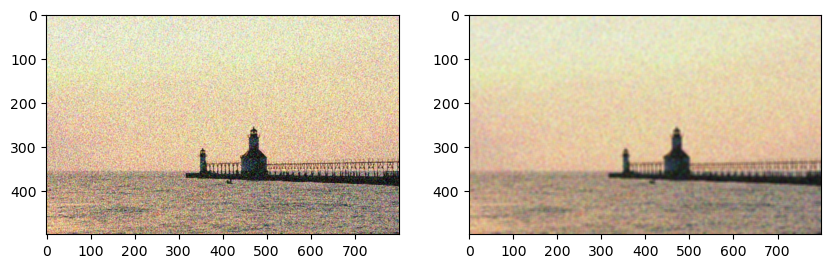

In [7]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

img = cv2.imread('ruido.jpg')

kernel7x7 = np.ones((7,7),np.float32)/49
suavizado2 = cv2.filter2D(img,-1,kernel7x7)

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(suavizado2,cv2.COLOR_BGR2RGB))

2. Usando la imagen rosa.png obtenga el siguiente resultado

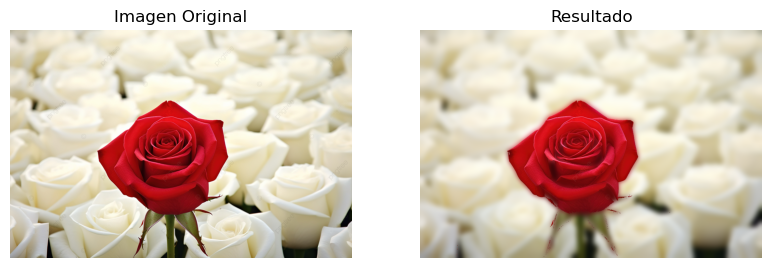

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('rosa.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

rojo_bajo1 = np.array([0, 100, 100])   
rojo_alto1 = np.array([10, 255, 255])   
rojo_bajo2 = np.array([160, 100, 100])  
rojo_alto2 = np.array([180, 255, 255])

mascara1 = cv2.inRange(imagen_hsv, rojo_bajo1, rojo_alto1)
mascara2 = cv2.inRange(imagen_hsv, rojo_bajo2, rojo_alto2)
mascara_rojo = mascara1 | mascara2
blanco_bajo = np.array([0, 0, 200])
blanco_alto = np.array([180, 50, 255])
mascara_blanco = cv2.inRange(imagen_hsv, blanco_bajo, blanco_alto)

imagen_desenfocada = cv2.GaussianBlur(imagen_rgb, (45, 45), 0)

imagen_salida = imagen_desenfocada.copy()
mascara_rojo_3ch = cv2.cvtColor(mascara_rojo, cv2.COLOR_RGB2BGR)
imagen_salida = np.where(mascara_rojo_3ch > 0, imagen_rgb, imagen_salida)
mascara_blanco_3ch = cv2.cvtColor(mascara_blanco, cv2.COLOR_RGB2BGR)
imagen_salida = np.where(mascara_blanco_3ch > 0, imagen_desenfocada, imagen_salida)
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Resultado')
plt.imshow(imagen_salida)
plt.axis('off')

plt.show()



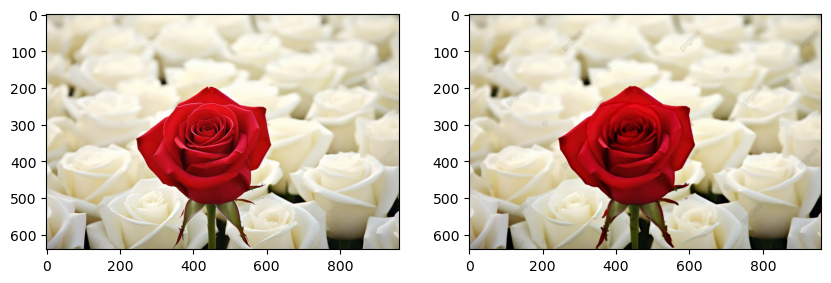

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('rosa.png')

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
kernel7x7=np.ones((7,7),np.float32)/49
img_rest=cv2.erode(imagen,kernel)
suavizado2=cv2.filter2D(img_rest,-1,kernel7x7)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(img_rest,cv2.COLOR_BGR2RGB))


3. Usando la imagen Elementos.jpg obtenga el siguiente resultado

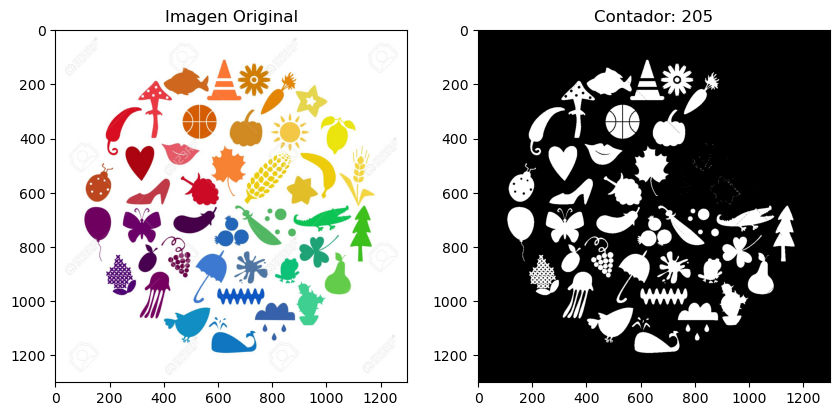

In [44]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def conteo2(imge):
    img_gray=cv2.cvtColor(imge,cv2.COLOR_BGR2GRAY)
    _,binarizada=cv2.threshold(img_gray,178,255,cv2.THRESH_BINARY_INV)
    contorno=measure.label(binarizada,connectivity=2)
    cont=np.max(contorno)
    return cont, binarizada
imagen=cv2.imread('elementos.jpg')
contado,bin=conteo2(imagen)
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.title(f'Contador: {contado}')
plt.imshow(bin,cmap='gray')

plt.show()


4. Usando la imagen de Cristo obtiene el siguiente resultado (utiliza máscaras de convolución)

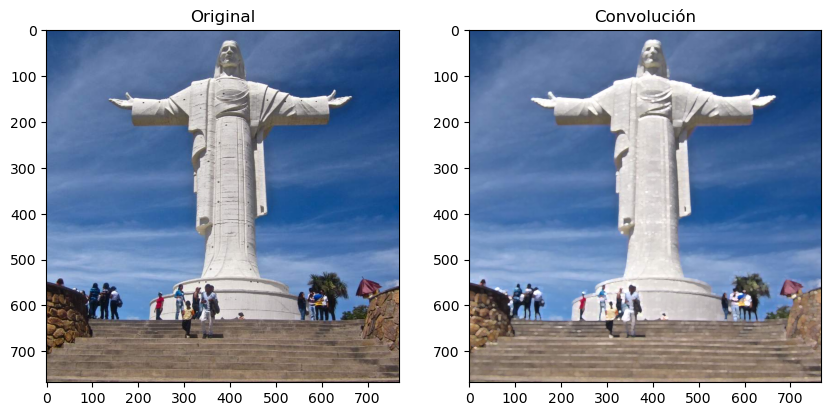

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen= cv2.imread('cristo.jpg')
kernel7x7 = np.ones((7,7),np.float32)/49
suavizado2 = cv2.filter2D(imagen,-1,kernel7x7)


kernel2=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#apertura=cv2.morphologyEx(suavizado2,cv2.MORPH_OPEN,kernel2)
apertura=cv2.dilate(imagen,kernel2)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(122)
plt.imshow(cv2.cvtColor(apertura,cv2.COLOR_BGR2RGB))
plt.title("Convolución")

plt.show()




5. Realiza una combinación de técnicas con una fotografía tuya (utiliza técnicas de bordes) explica las diferencias

C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_7384\2040696576.py:91: RuntimeWarning: invalid value encountered in sqrt
  magnitud = np.sqrt(sobelx**2 + sobely**2)


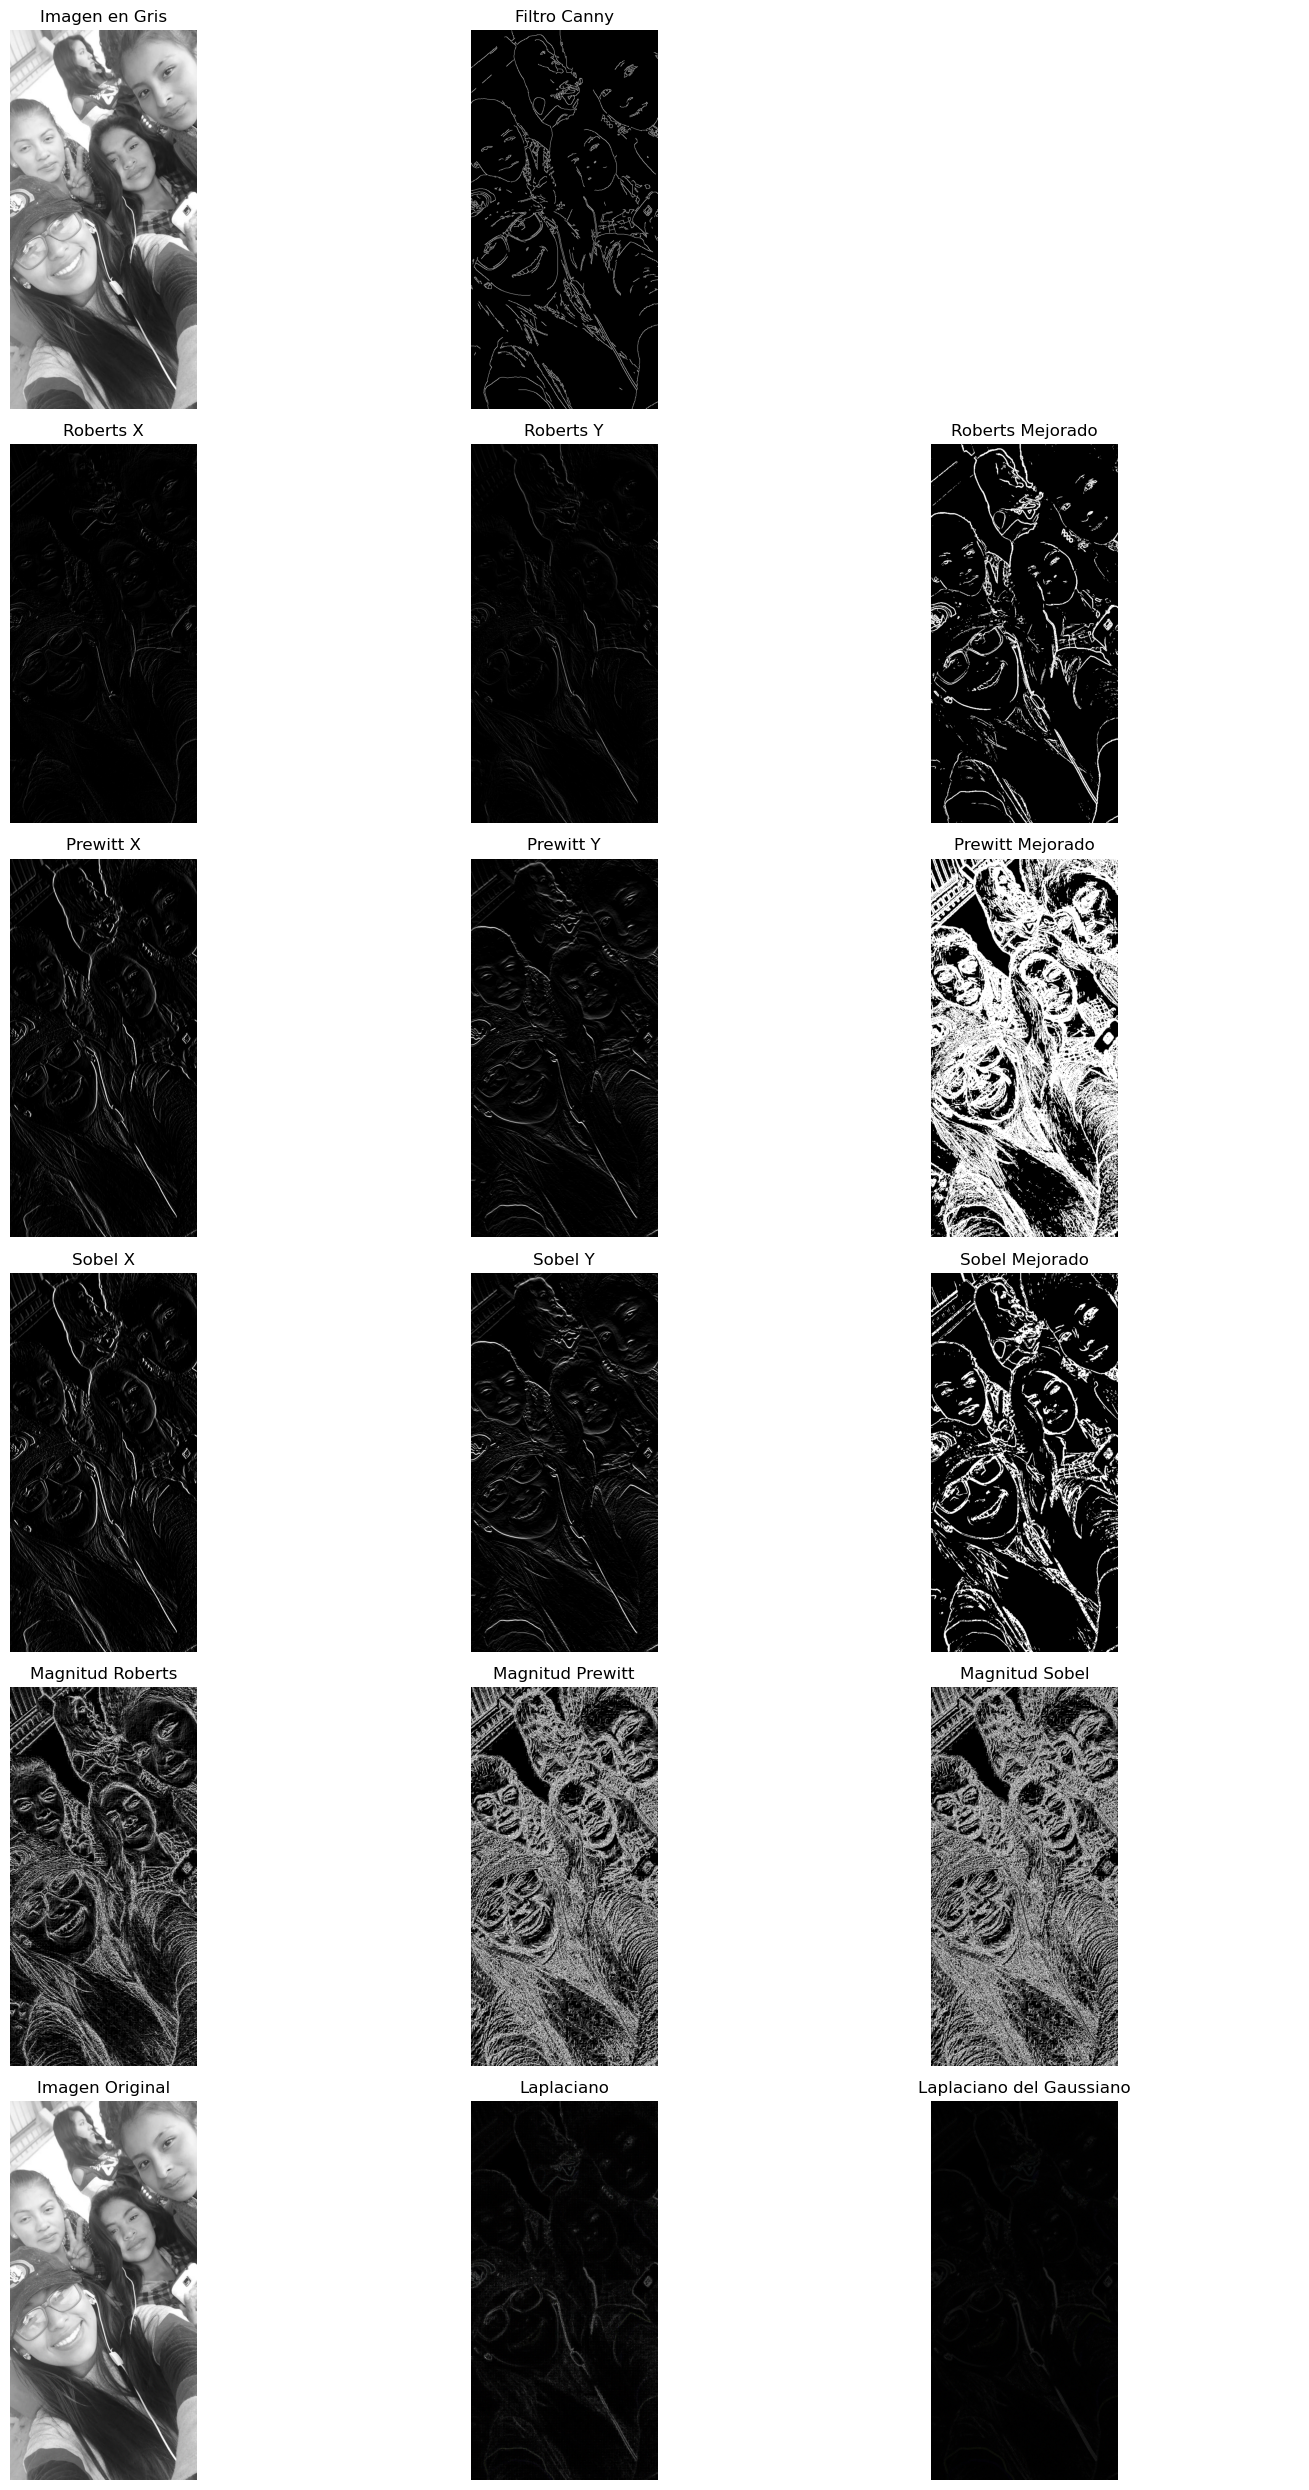

In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('T2.jpeg')
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# filtro Roberts
# Kernel 
robertsx = np.array([[-1, 0], [0, 1]])
robertsy = np.array([[0, -1], [1, 0]])

img_robx = cv2.filter2D(img_gray, -1, robertsx)
img_roby = cv2.filter2D(img_gray, -1, robertsy)

rob_gmagnitud = np.sqrt(img_robx**2 + img_roby**2)
rob_gmagnitud = np.uint8(rob_gmagnitud)
rob_gdireccion = np.arctan2(img_roby,img_robx)

#Roberts mejorado
def roberts_mejorado(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

    kernelx = np.array([[-2, 0], [0, 2]], dtype=np.float32)
    kernely = np.array([[0, 2], [-2, 0]], dtype=np.float32)

    robx = cv2.filter2D(suavizado, cv2.CV_16S, kernelx)
    roby = cv2.filter2D(suavizado, cv2.CV_16S, kernely)

    roberts = cv2.addWeighted(np.abs(robx), 0.7, np.abs(roby), 0.7, 0)
    roberts = np.uint8(np.clip(roberts, 0, 255))

    _, bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)

    return bordes

bordes_roberts = roberts_mejorado(imagen)

# filstro prewitT
# kernels
prewittx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitty = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

img_prx = cv2.filter2D(img_gray, -1, prewittx)
img_pry = cv2.filter2D(img_gray, -1, prewitty)

prew_mag = np.sqrt(img_prx**2 + img_pry**2)
prew_mag = np.uint8(prew_mag)
prew_dir = np.arctan2(prewitty,prewittx)

#Prewitt mejorado
def prewitt_mejor(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    prewittx = np.array([[3, 0, -3], [3, 0, -3], [3, 0, -3]], dtype=np.float32)
    prewitty = np.array([[3, 3, 3], [0, 0, 0], [-3, -3, -3]], dtype=np.float32)

    x = cv2.filter2D(img_gray, cv2.CV_64F, prewittx)
    y = cv2.filter2D(img_gray, cv2.CV_64F, prewitty)

    magnitud = np.sqrt(x**2 + y**2)
    _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
    bordes = np.uint8(bordes)

    return bordes

bordes_prewitt = prewitt_mejor(imagen)

# filtro sobel
# kernel
sobelx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
sobely = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

img_sobx = cv2.filter2D(img_gray, -1, sobelx)
img_soby = cv2.filter2D(img_gray, -1, sobely)

sob_mag = np.sqrt(img_sobx**2 + img_soby**2)
sob_mag = np.uint8(sob_mag)
sob_dir = np.arctan2(sobely,sobelx)

#Sobel mejorado
def sobel_mejor(imagen, tam_kernel=3, umbral=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    sobelx = cv2.Sobel(img_gray, cv2.CV_16S, 1, 0, ksize=tam_kernel)
    sobely = cv2.Sobel(img_gray, cv2.CV_16S, 0, 1, ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2 + sobely**2)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel_morf = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
    return bordes

bordes_sobel = sobel_mejor(imagen)

# Filtro CANNY
canny = cv2.Canny(img_gray, 100, 200)


#filtro Laplaciano y Laplaciano del Gaussiano
# Laplaciano
laplaciano = cv2.Laplacian(imagen, cv2.CV_64F)
laplaciano = np.uint8(np.absolute(laplaciano))
# Laplaciano del Gaussiano
gaussiano = cv2.GaussianBlur(imagen, (5, 5), 0)

log = cv2.Laplacian(gaussiano, cv2.CV_64F)
log = np.uint8(np.absolute(log))

fig, axs = plt.subplots(6, 3, figsize=(15, 25))
axs[0][0].imshow(img_gray, cmap='gray')
axs[0][0].set_title('Imagen en Gris')
axs[0][0].axis('off')

axs[0][1].imshow(canny, cmap='gray')
axs[0][1].set_title('Filtro Canny')
axs[0][1].axis('off')

axs[0][2].axis('off')  

axs[1][0].imshow(img_robx, cmap='gray')
axs[1][0].set_title('Roberts X')
axs[1][0].axis('off')

axs[1][1].imshow(img_roby, cmap='gray')
axs[1][1].set_title('Roberts Y')
axs[1][1].axis('off')

axs[1][2].imshow(bordes_roberts, cmap='gray')
axs[1][2].set_title('Roberts Mejorado')
axs[1][2].axis('off')

axs[2][0].imshow(img_prx, cmap='gray')
axs[2][0].set_title('Prewitt X')
axs[2][0].axis('off')

axs[2][1].imshow(img_pry, cmap='gray')
axs[2][1].set_title('Prewitt Y')
axs[2][1].axis('off')

axs[2][2].imshow(bordes_prewitt, cmap='gray')
axs[2][2].set_title('Prewitt Mejorado')
axs[2][2].axis('off')

axs[3][0].imshow(img_sobx, cmap='gray')
axs[3][0].set_title('Sobel X')
axs[3][0].axis('off')

axs[3][1].imshow(img_soby, cmap='gray')
axs[3][1].set_title('Sobel Y')
axs[3][1].axis('off')

axs[3][2].imshow(bordes_sobel, cmap='gray')
axs[3][2].set_title('Sobel Mejorado')
axs[3][2].axis('off')

axs[4][0].imshow(rob_gmagnitud, cmap='gray')
axs[4][0].set_title('Magnitud Roberts')
axs[4][0].axis('off')

axs[4][1].imshow(prew_mag, cmap='gray')
axs[4][1].set_title('Magnitud Prewitt')
axs[4][1].axis('off')

axs[4][2].imshow(sob_mag, cmap='gray')
axs[4][2].set_title('Magnitud Sobel')
axs[4][2].axis('off')

axs[5][0].imshow(img_gray, cmap='gray')
axs[5][0].set_title('Imagen Original')
axs[5][0].axis('off')

axs[5][1].imshow(laplaciano, cmap='gray')
axs[5][1].set_title('Laplaciano')
axs[5][1].axis('off')

axs[5][2].imshow(log, cmap='gray')
axs[5][2].set_title('Laplaciano del Gaussiano')
axs[5][2].axis('off')

plt.tight_layout()
plt.show()


CONCEPTO DE BORDES
Filtro Roberts: Identifica los bordes una manera más exacta, muestra una imagen con bordes más limpios.
Filtro Prewitt: La identificación de bordes son un poco más borrosas y gruesas, se muestra mucho ruido
Filtro Sobel: Los bordes identificados suele verse un poco más gruesos y segmentadas.
Filtro Canny: Suele ser uno de los filtros más simples ya que identifica los bordes de manera clara y sin ruido
Laplaciano: Identifica los bordes la imagen de una manera no muy clara.
Laplaciano del Gaussiano: Sualmente se usa para disminuir el ruido de la imagen para que se identifique los bordes de manera adecuada.


6. Realizar el cógigo del lapaciano y lapaciono del gausiano mejorando los bordes (deben verse más nítidos los bordes encontrados)

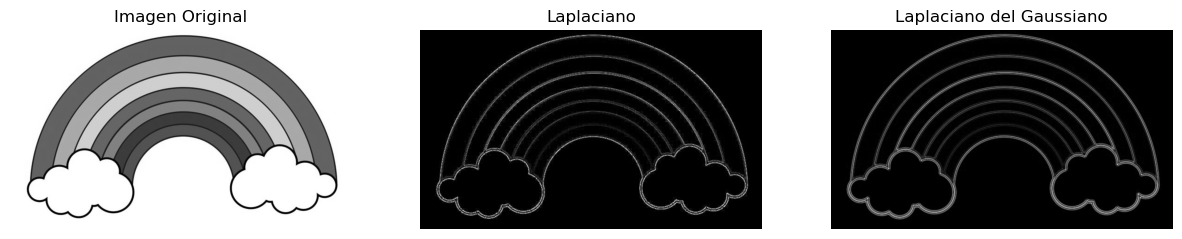

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
laplaciano = cv2.Laplacian(imagen, cv2.CV_64F)
laplaciano = np.uint8(np.absolute(laplaciano))
gaussiano = cv2.GaussianBlur(imagen, (5, 5), 0)

log = cv2.Laplacian(gaussiano, cv2.CV_64F)
log = np.uint8(np.absolute(log))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Laplaciano')
plt.imshow(laplaciano, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Laplaciano del Gaussiano')
plt.imshow(log, cmap='gray')
plt.axis('off')
plt.show()